In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. read in data

In [6]:
df_two = pd.read_csv('/Users/ashleytarrant/Desktop/two slit/double_slit.csv')
df_left = pd.read_csv('/Users/ashleytarrant/Desktop/two slit/position_2_singleslit.csv')
df_right = pd.read_csv('/Users/ashleytarrant/Desktop/two slit/position_4_single_slit.csv')

In [7]:
x_pos3, V_pos3, Vflag_pos3 = df_two.x, df_two.voltage, df_two.mv_or_no
x_pos2, V_pos2, Vflag_pos2 = df_left.x, df_left.voltage, df_left.mv_or_no
x_pos4, V_pos4, Vflag_pos4 = df_right['x (mm)'], df_right.voltage, df_right.mV_or_no

(2.0, 6.0)

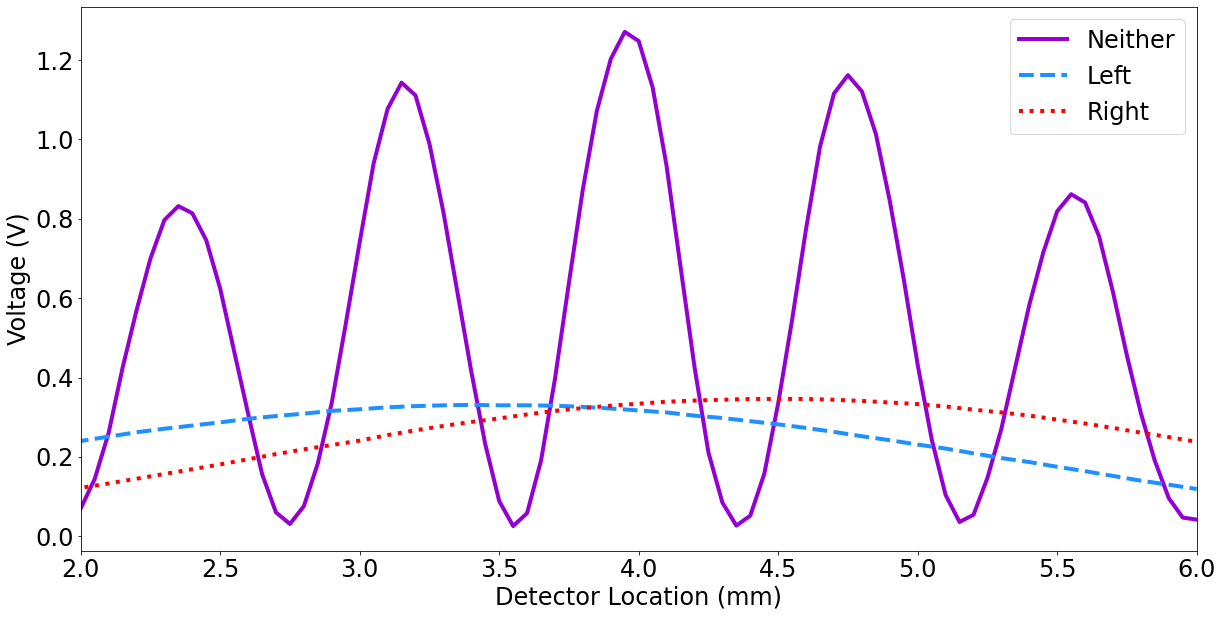

In [8]:
fig = plt.figure(figsize=(20,10))
fs = 24

plt.plot(x_pos3, V_pos3, label='Neither', c='darkviolet', linewidth=4)
plt.plot(x_pos2, V_pos2, ls='--', label='Left', c='dodgerblue',linewidth=4)
plt.plot(x_pos4, V_pos4, ls=':', label='Right', c='red',linewidth=4)
plt.legend(fontsize=fs)

plt.xlabel('Detector Location (mm)', fontsize=fs)
plt.ylabel('Voltage (V)', fontsize=fs)

plt.xticks(fontsize=fs)
plt.yticks(fontsize=fs)

plt.xlim(2,6)

## Fit the data

In [9]:
from scipy.optimize import curve_fit

In [10]:
def I_single(x, A, x_o, I_o):
    return I_o * (np.sin(A * (x - x_o)) / (A * (x - x_o)))**2.

In [11]:
popt_sing_pos2_uw, popt_cov_sing_pos2_uw = curve_fit(I_single, x_pos2, V_pos2, bounds=([0,np.inf]))
popt_sing_pos4_uw, popt_cov_sing_pos4_uw = curve_fit(I_single, x_pos4, V_pos4, bounds=([0,np.inf]))

(1.8, 6.1)

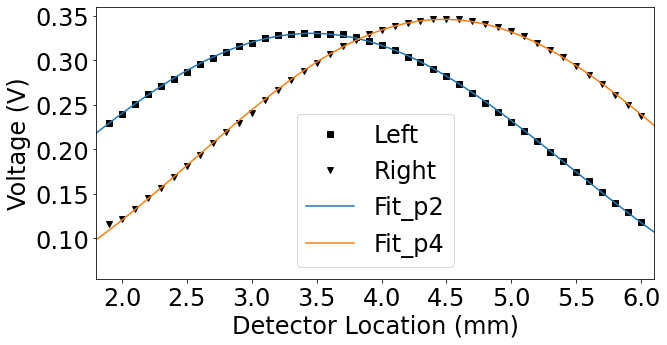

In [12]:
fig = plt.figure(figsize=(10,5))
fs = 24

plt.plot(x_pos2, V_pos2, 'sk', label='Left')
plt.plot(x_pos4, V_pos4, 'vk', label='Right')

xarr = np.linspace(1.5,6.5,100)
plt.plot(xarr, I_single(xarr, popt_sing_pos2_uw[0], popt_sing_pos2_uw[1], popt_sing_pos2_uw[2]), label='Fit_p2')
plt.plot(xarr, I_single(xarr, popt_sing_pos4_uw[0], popt_sing_pos4_uw[1], popt_sing_pos4_uw[2]), label='Fit_p4')


plt.legend(fontsize=fs)

plt.xlabel('Detector Location (mm)', fontsize=fs)
plt.ylabel('Voltage (V)', fontsize=fs)

plt.xticks(fontsize=fs)
plt.yticks(fontsize=fs)

plt.xlim(1.8,6.1)

## refit with error

In [13]:
def calc_V_err(V_meas, which_range):
    V_err = np.zeros(len(V_meas))
    for i, meas in enumerate(V_meas):
        
        ## 0-200 mV range error 
        if which_range[i] == 0:
            V_err[i] = 0.0004 * meas + 0.0009 * 0.2

        ## 200mV - 2V error
        else:
            V_err[i] = 0.0004 * meas + 0.0008 * 2.
            
    return V_err

def dI_sing_dx(x, A, x_o, I_o):
    X = x - x_o
    numer = -2. * np.sin(A*X) * (np.sin(A*X) + (A * x_o - A * x) * np.cos(X))
    denom = A**2. * X**3.
    return I_o * numer / denom

In [14]:
V_err_pos2 = calc_V_err(V_pos2, Vflag_pos2)
V_err_pos4 = calc_V_err(V_pos4, Vflag_pos4)

#### refit

In [15]:
xerr = 0.005 # mm
yerr = 0.0005 # V

curr_A = np.mean((popt_sing_pos2_uw[0],popt_sing_pos4_uw[0]))
curr_xo = np.mean((popt_sing_pos2_uw[1],popt_sing_pos4_uw[1]))
curr_Io = np.mean((popt_sing_pos2_uw[2],popt_sing_pos4_uw[2]))

sigma_tot_pos2 = np.sqrt(V_err_pos2**2. + xerr**2. * dI_sing_dx(x_pos2, curr_A, curr_xo, curr_Io)**2.)
sigma_tot_pos4 = np.sqrt(V_err_pos4**2. + xerr**2. * dI_sing_dx(x_pos4, curr_A, curr_xo, curr_Io)**2.)

In [16]:
popt_sing_pos2, popt_cov_sing_pos2 = curve_fit(I_single, x_pos2, V_pos2, bounds=([0,np.inf]), sigma=sigma_tot_pos2)
popt_sing_pos4, popt_cov_sing_pos4 = curve_fit(I_single, x_pos4, V_pos4, bounds=([0,np.inf]), sigma=sigma_tot_pos4)

errors_pos2 = np.sqrt(np.diag(popt_cov_sing_pos2))
errors_pos4 = np.sqrt(np.diag(popt_cov_sing_pos4))

In [17]:
params = ["A", "x_o", "I_o"]
for i in range(3):
    print(params[i])
    print(round(popt_sing_pos2[i],5), '+/-', round(errors_pos2[i],5))
    print(round(popt_sing_pos4[i],5), '+/-', round(errors_pos4[i],5))

A
0.65995 +/- 0.00131
0.68135 +/- 0.00136
x_o
3.46077 +/- 0.0024
4.47767 +/- 0.00236
I_o
0.33085 +/- 0.00016
0.34636 +/- 0.00017


(1.8, 6.1)

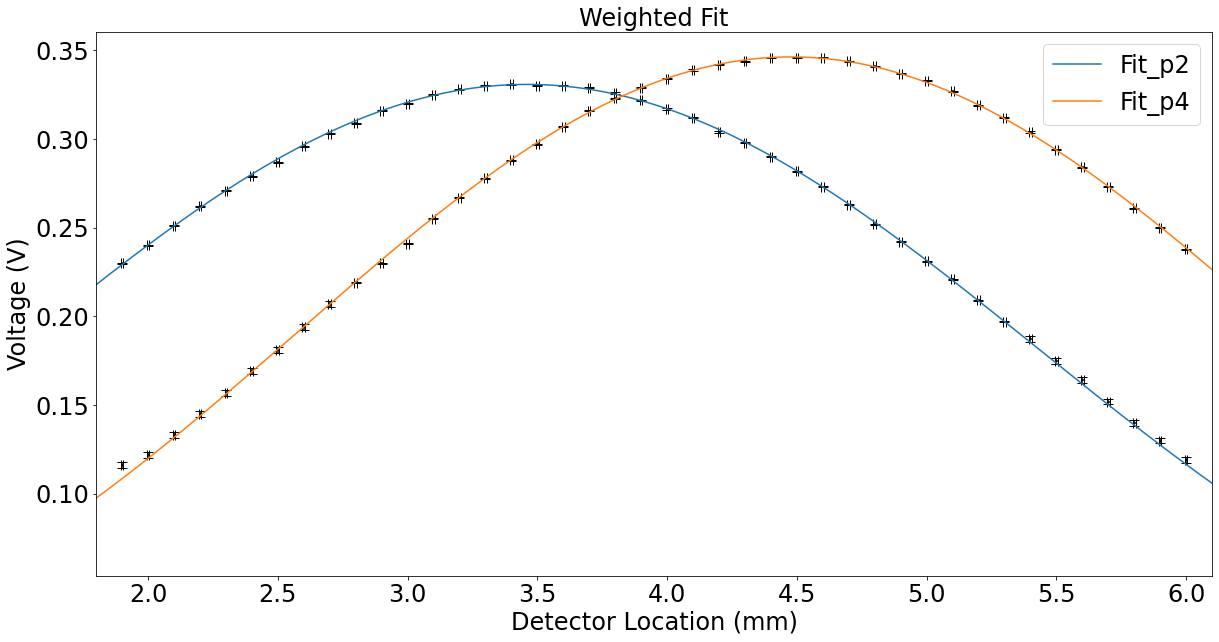

In [18]:
fig = plt.figure(figsize=(20,10))
fs = 24

#plt.plot(x_pos2, V_pos2, 'sk', label='Left')
plt.errorbar(x_pos2, V_pos2, xerr=xerr, yerr=V_err_pos2, ls='none', c='k', capsize=5)
#plt.plot(x_pos4, V_pos4, 'vk', label='Right')
plt.errorbar(x_pos4, V_pos4, xerr=xerr, yerr=V_err_pos4, ls='none', c='k', capsize=5)

xarr = np.linspace(1.5,6.5,1000)
plt.plot(xarr, I_single(xarr, popt_sing_pos2[0], popt_sing_pos2[1], popt_sing_pos2[2]), label='Fit_p2')
plt.plot(xarr, I_single(xarr, popt_sing_pos4[0], popt_sing_pos4[1], popt_sing_pos4[2]), label='Fit_p4')


plt.legend(fontsize=fs)

plt.xlabel('Detector Location (mm)', fontsize=fs)
plt.ylabel('Voltage (V)', fontsize=fs)
plt.title('Weighted Fit', fontsize=fs)

plt.xticks(fontsize=fs)
plt.yticks(fontsize=fs)

plt.xlim(1.8,6.1)

In [19]:
Red_Chi_Sq_pos2= 1./(len(x_pos2)-3.)*np.sum((V_pos2-I_single(x_pos2, popt_sing_pos2[0], popt_sing_pos2[1], popt_sing_pos2[2]))**2/sigma_tot_pos2)
Red_Chi_Sq_pos4= 1./(len(x_pos4)-3.)*np.sum((V_pos4-I_single(x_pos4, popt_sing_pos4[0], popt_sing_pos4[1], popt_sing_pos4[2]))**2/sigma_tot_pos4)



In [20]:
print(Red_Chi_Sq_pos2, Red_Chi_Sq_pos4)

0.0008127791015373415 0.0013228810966515693


Recall that
$A = \frac{\pi a}{\lambda D}$

sovle for slit width $a$ and the uncertainty for each slit

In [21]:
def calc_param(wv, dist, p):
    return wv * dist * p / np.pi

def calc_param_err(wv, dist, param, err_wv, err_dist, err_param):
    wv_contr = (dist * param / np.pi)**2. * err_wv**2.
    D_contr = (wv * param / np.pi)**2. * err_dist**2.
    param_contr = (wv * dist / np.pi)**2. * err_param**2.
    
    return np.sqrt(wv_contr + D_contr + param_contr)

In [22]:
# laser wavelength and error
lam, lam_err = 670., 5.                # nm
lam, lam_err = lam*1e-6, lam_err*1e-6  # mm

# length of box and error
D, D_err = 496.0, 5.     # mm

In [23]:
# solve for slit width
a_left = calc_param(lam, D, popt_sing_pos2[0])
a_right = calc_param(lam, D, popt_sing_pos4[0])

# propagate the error by adding uncertainties in quadrature
a_left_err = calc_param_err(lam, D, popt_sing_pos2[0], lam_err, D_err, errors_pos2[0]) 
a_right_err = calc_param_err(lam, D, popt_sing_pos4[0], lam_err, D_err, errors_pos4[0]) 

In [24]:
# calculate a weighted average of the final estimate

a_meas = np.average((a_left, a_right), weights=(a_left_err,a_right_err))
a_meas_err = np.sqrt(a_left_err**2. + a_right_err**2.)
print(a_meas, a_meas_err)

0.07095998762827666 0.0012742074676264032


In [25]:
(0.085 - a_meas) / a_meas_err

11.018623519666795

#### HOMEWORK PROBLEM

In [26]:
# a_hw = calc_param(670.*1e-6, 500., 0.942)
# a_hw_err = calc_param_err(670.*1e-6, 500., 0.942, 5e-6, 5, 0.001)

# print(a_hw,a_hw_err)

# b_hw = calc_param(670.*1e-6, 500., 4.261)
# b_hw_err = calc_param_err(670.*1e-6, 500., 4.261, 5e-6, 5, 0.001)

# print(b_hw,b_hw_err)

## Now solve for slit separation $b$ and its uncertainty

Recall that $B = \frac{\pi b}{\lambda D}$

sensitive to initial parameters, so use our best guesses to initialize

In [27]:
A_meas = np.average((popt_sing_pos2[0], popt_sing_pos4[0]),weights=(errors_pos2[0],errors_pos4[0]))
print(A_meas)

x_o_meas = np.average((popt_sing_pos2[1], popt_sing_pos4[1]),weights=(errors_pos2[1],errors_pos4[1]))
print(x_o_meas)

I_o_meas = np.average((popt_sing_pos2[2], popt_sing_pos4[2]),weights=(errors_pos2[2],errors_pos4[2]))
print(I_o_meas)

0.67083782073687
3.964812150238059
0.3388832003185141


In [28]:
b_guess = 0.457 # mm guess
B_guess = np.pi * b_guess / (lam * D)
print(B_guess)

4.320257109685048


In [29]:
def I_double(x, B, A, Io, xo):
    return 4. * Io * ((np.sin(A * (x - xo)))**2. / (A * (x - xo))**2.) * (np.cos(B * (x - xo)))**2.

def dI_doub_dx(x, B, A, Io, xo):
    X = x - xo
    term1 = -8. * np.sin(A * X) * np.cos(B * X) * ((B*x - B*xo) * np.sin(A * X) * np.sin(B * X))
    term2 = np.sin(A * X) + (A*xo - A*x) * np.cos(A * X) * np.cos(B * X)
    denom = A**2. * X**3.
    return Io * (term1 + term2) / denom

In [30]:
popt_doub_uw, popt_cov_doub_uw = curve_fit(I_double, x_pos3, V_pos3, p0=[B_guess, A_meas, 1.2, x_o_meas])

(1.8, 6.1)

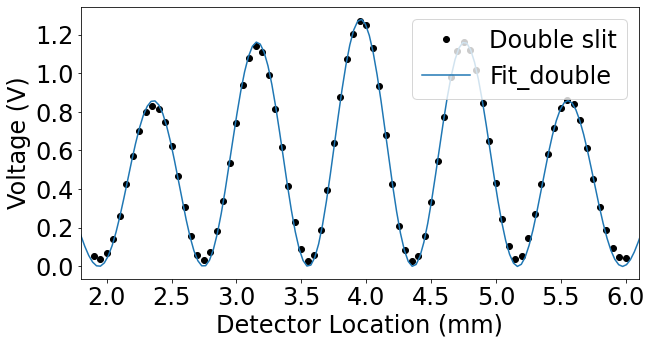

In [31]:
fig = plt.figure(figsize=(10,5))
fs = 24

plt.plot(x_pos3, V_pos3, 'ok', label='Double slit')

xarr = np.linspace(-10,20,1000)
plt.plot(xarr, I_double(xarr, popt_doub_uw[0], popt_doub_uw[1], popt_doub_uw[2], popt_doub_uw[3]), label='Fit_double')


plt.legend(fontsize=fs)

plt.xlabel('Detector Location (mm)', fontsize=fs)
plt.ylabel('Voltage (V)', fontsize=fs)

plt.xticks(fontsize=fs)
plt.yticks(fontsize=fs)

plt.xlim(1.8,6.1)

### refit with errors

In [32]:
# get correct errors
V_err_pos3 = calc_V_err(V_pos3, Vflag_pos3)
sigma_tot_pos3 = np.sqrt(V_err_pos3**2. + xerr**2. * dI_doub_dx(x_pos3, popt_doub_uw[0], popt_doub_uw[1], popt_doub_uw[2], popt_doub_uw[3])**2.)


# recalculate the fit
popt_doub, popt_cov_doub = curve_fit(I_double, x_pos3, V_pos3, bounds=([0,np.inf]), p0=[B_guess, A_meas, 1.2, x_o_meas], sigma=sigma_tot_pos3)
errors_doub = np.sqrt(np.diag(popt_cov_doub))

In [33]:
params = ["B", "A", "x_o", "I_o"]
for i in range(4):
    print(params[i])
    print(round(popt_doub[i],5), '+/-', round(errors_doub[i],5))

B
3.87644 +/- 0.00664
A
0.67822 +/- 0.00543
x_o
0.31655 +/- 0.00145
I_o
3.9607 +/- 0.0018


(1.8, 6.1)

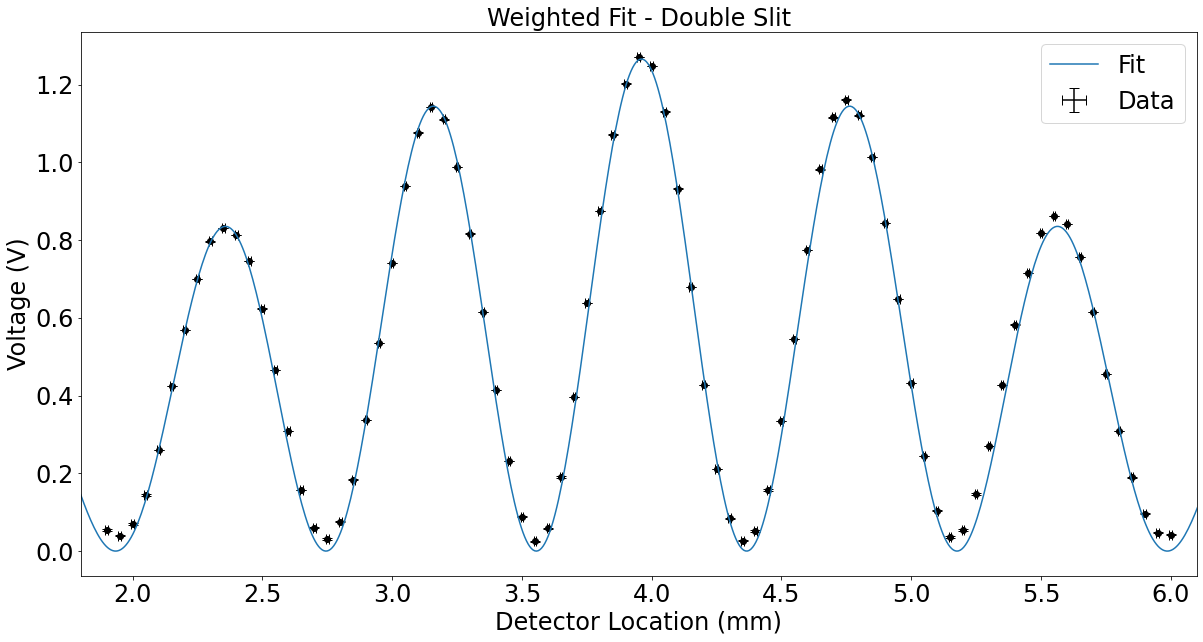

In [34]:
fig = plt.figure(figsize=(20,10))
fs = 24

plt.plot(x_pos3, V_pos3, 'ok')
plt.errorbar(x_pos3, V_pos3, xerr=xerr, yerr=V_err_pos3, ls='none', c='k', capsize=5, label='Data')

xarr = np.linspace(1.5,8,1000)
plt.plot(xarr, I_double(xarr, popt_doub[0], popt_doub[1], popt_doub[2], popt_doub[3]), label='Fit')

plt.legend(fontsize=fs)

plt.xlabel('Detector Location (mm)', fontsize=fs)
plt.ylabel('Voltage (V)', fontsize=fs)
plt.title('Weighted Fit - Double Slit', fontsize=fs)

plt.xticks(fontsize=fs)
plt.yticks(fontsize=fs)

plt.xlim(1.8,6.1)

In [35]:
Red_Chi_Sq_doub = 1./(len(x_pos3)-4.)*np.sum((V_pos3-I_double(x_pos3, popt_doub[0], popt_doub[1], popt_doub[2], popt_doub[3]))**2/sigma_tot_pos3)
print(Red_Chi_Sq_doub)

0.09586393931835295


In [36]:
# solve for slit separation
b_meas = calc_param(lam, D, popt_doub[0])
b_meas_err = calc_param_err(lam, D, popt_doub[0], lam_err, D_err, errors_doub[0]) 

print(b_meas, b_meas_err)

0.41005248288790297 0.00519071835619116


In [37]:
act_b = .406 # mm
print(abs(act_b - b_meas)/b_meas_err)

0.7807171589399369
